In [1]:
import pickle
import numpy as np
with open("../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/data_batch_1", 'rb') as fo:
    data_dict = pickle.load(fo, encoding='bytes')

C:\Users\apmal\AppData\Local\Temp\ipykernel_25148\2667530960.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(fo, encoding='bytes')


In [3]:
data_dict.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [5]:
data_dict[b'batch_label']

b'training batch 1 of 5'

In [6]:
len(data_dict[b'labels'])

10000

In [10]:
from collections import Counter
cl = Counter()
cl.update(data_dict[b'labels'])


In [11]:
cl

Counter({2: 1032,
         6: 1030,
         8: 1025,
         3: 1016,
         0: 1005,
         7: 1001,
         4: 999,
         9: 981,
         1: 974,
         5: 937})

In [12]:
len(data_dict[b'data'])

10000

In [13]:
data_dict[b'data'][0].shape

(3072,)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [12]:
img_data = data_dict[b'data'][0]
img_data = np.dstack([img_data[i: i + 1024].reshape((32, 32)) for i in range(0, len(data_dict[b'data'][0]), 1024)]).astype(np.uint8)

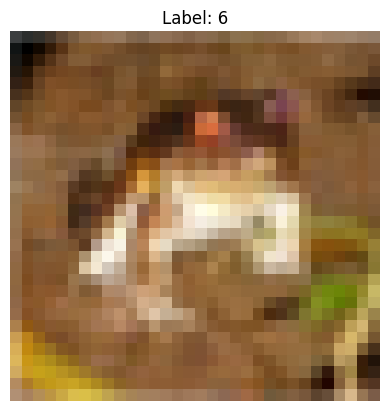

In [17]:
plt.imshow(img_data)
plt.axis('off')
plt.title("Label: " + str(data_dict[b'labels'][0]))
plt.show()

In [26]:
import pickle
import numpy as np
with open("../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/batches.meta", 'rb') as fo:
    data_meta = pickle.load(fo, encoding='bytes')

In [19]:
data_meta

{b'num_cases_per_batch': 10000,
 b'label_names': [b'airplane',
  b'automobile',
  b'bird',
  b'cat',
  b'deer',
  b'dog',
  b'frog',
  b'horse',
  b'ship',
  b'truck'],
 b'num_vis': 3072}

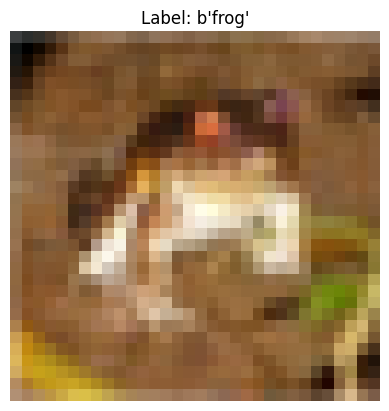

In [22]:
plt.imshow(img_data)
plt.axis('off')
plt.title("Label: " + str(data_meta[b'label_names'][data_dict[b'labels'][0]]))
plt.show()

In [23]:
import pickle
import numpy as np
with open("../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/test_batch", 'rb') as fo:
    data_test = pickle.load(fo, encoding='bytes')

C:\Users\apmal\AppData\Local\Temp\ipykernel_25148\2822970727.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_test = pickle.load(fo, encoding='bytes')


In [24]:
len(data_test[b'labels'])

10000

In [25]:
import polars as pl

In [39]:
d = {
    "label": [data_dict[b'labels'][0]],
    "label_names": [data_meta[b'label_names'][data_dict[b'labels'][0]].decode("utf-8")]
}

In [40]:
df = pl.DataFrame(d)

In [41]:
df.with_columns(pl.Series("data", [img_data], dtype=pl.Object))

label,label_names,data
i64,str,object
6,"""frog""",[[[ 59 62 63] [ 43 46 45] [ 50 48 43] ... [158 132 108] [152 125 102] [148 124 103]] [[ 16 20 20] [ 0 0 0] [ 18 8 0] ... [123 88 55] [119 83 50] [122 87 57]] [[ 25 24 21] [ 16 7 0] [ 49 27 8] ... [118 84 50] [120 84 50] [109 73 42]] ... [[208 170 96] [201 153 34] [198 161 26] ... [160 133 70] [ 56 31 7] [ 53 34 20]] [[180 139 96] [173 123 42] [186 144 30] ... [184 148 94] [ 97 62 34] [ 83 53 34]] [[177 144 116] [168 129 94] [179 142 87] ... [216 184 140] [151 118 84] [123 92 72]]]


In [ ]:
import os
os.listdir("../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/")

['batches.meta',
 'data_batch_1',
 'data_batch_2',
 'data_batch_3',
 'data_batch_4',
 'data_batch_5',
 'readme.html',
 'test_batch']

In [59]:
import os
import pickle

def read_pkl(path: str) -> dict:
    with open(path, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d 

def make_df(path: str, metadata: dict) -> pl.DataFrame:
    d = read_pkl(path)
    img_data = [np.dstack([img[i: i + 1024].reshape((32, 32)) for i in range(0, len(img), 1024)]).astype(np.uint8) for img in d[b'data']]
    _data_dict = {
        "label": d[b'labels'],
        "label_names": [metadata[b'label_names'][l].decode("utf-8") for l in d[b'labels']]
    }
    _df = pl.DataFrame(_data_dict)
    _df = _df.with_columns(pl.Series("data", img_data, dtype=pl.Object))
    return _df

def read_data(path: str) -> tuple[pl.DataFrame]:
    meta = os.path.join(path, "batches.meta")
    train_pref = "data_batch_"
    test_pref = "test"
    
    files = os.listdir(path)
    
    metadata = read_pkl(meta)
    
    train_data = []
    test_data = []
    for file in files:
        if file.startswith(train_pref):
            train_data.append(make_df(os.path.join(path, file), metadata))
        elif file.startswith(test_pref):
            test_data.append(make_df(os.path.join(path, file), metadata))
    
    return pl.concat(train_data, how="vertical"), pl.concat(test_data, how="vertical")

In [60]:
train_df, test_df = read_data("../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/")

C:\Users\apmal\AppData\Local\Temp\ipykernel_25148\3279090848.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


In [62]:
train_df["data"][0].shape

(32, 32, 3)

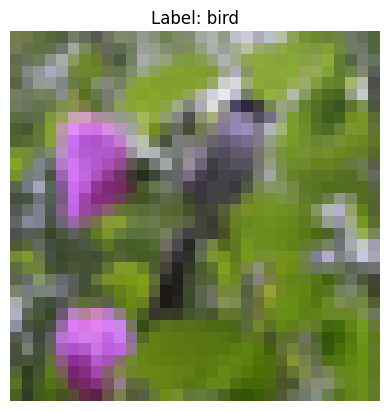

In [65]:
j = 300
plt.imshow(train_df["data"][j])
plt.axis('off')
plt.title("Label: " + train_df["label_names"][j])
plt.show()